In [22]:
# Imports and configuration
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(seed=42)

plt.rcParams.update({
    "figure.dpi": 120,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.labelsize": 12,
    "font.family": "serif",
})

import time
from IPython.display import display, clear_output

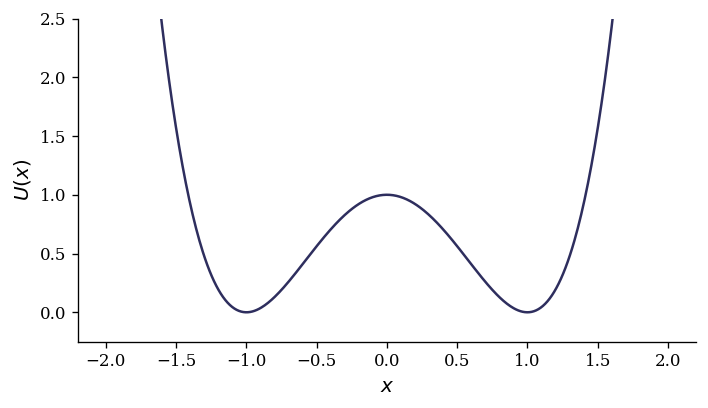

In [149]:
# Define and plot the double-well potential

#def U(x):
#    return (x**2 - 1)**2
def U(x, bias=0.0):
    return (x**2 - 1)**2 + bias * x+np.abs(bias)
    
x = np.linspace(-2, 2, 500)

fig, ax = plt.subplots(figsize=(6, 3.5))
ax.plot(x, U(x), color="#2e2e5e")
ax.set_xlabel(r"$x$")
ax.set_ylabel(r"$U(x)$")
ax.set_ylim(-0.25, 2.5)
plt.tight_layout()
plt.show()

In [150]:
# The Metropolis step
def metropolis_step(x_current, beta, step_size, rng):
    # Propose a move and accept or reject it via the Metropolis criterion.
    # Returns the next position (which may be the same as x_current).

    # Propose
    x_proposed = x_current + rng.uniform(-step_size, step_size)

    # Energy difference
    delta_U = U(x_proposed) - U(x_current)

    # Accept or reject
    if delta_U <= 0:
        return x_proposed
    elif rng.random() < np.exp(-beta * delta_U):
        return x_proposed
    else:
        return x_current

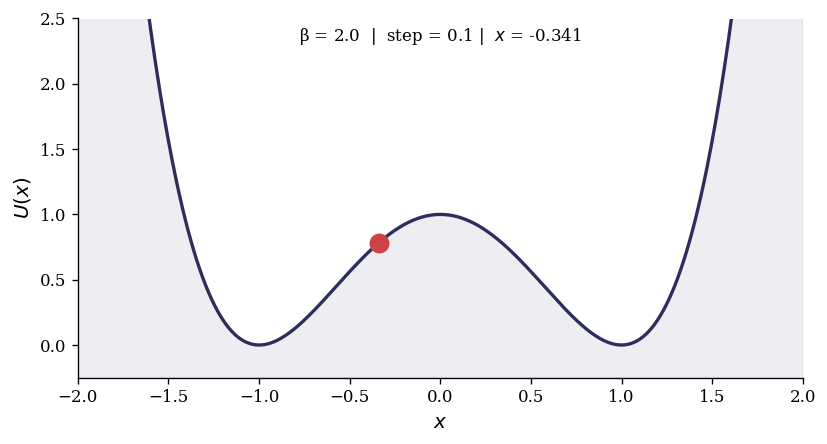

In [151]:
# Animated particle on the potential landscape
N_FRAMES   = 100     # number of animation frames
STEPS_PER_FRAME = 20  # MC steps between frames (speeds up the motion)
beta_anim  = 2.00
step_anim  = 0.1

x_dot = rng.uniform(-2, 2)  # start at a random position

for frame in range(N_FRAMES):

    # advance the chain a few steps before each frame
    for _ in range(STEPS_PER_FRAME):
        x_proposed = x_dot + rng.uniform(-step_anim, step_anim)
        delta_U    = U(x_proposed) - U(x_dot)
        if delta_U <= 0 or rng.random() < np.exp(-beta_anim * delta_U):
            x_dot = x_proposed

    fig, ax = plt.subplots(figsize=(7, 3.8))

    # potential curve
    ax.plot(x, U(x), color="#2e2e5e", lw=2, zorder=1)
    ax.fill_between(x, U(x), -0.25, alpha=0.08, color="#2e2e5e", zorder=0)
    # the particle
    ax.scatter([x_dot], [U(x_dot)], color="#cc4444", s=120, zorder=5, clip_on=False)
    ax.set_xlim(-2., 2.)
    ax.set_ylim(-0.25, 2.5)
    ax.set_xlabel(r"$x$")
    ax.set_ylabel(r"$U(x)$")
    ax.text(0.5, 0.92, f"β = {beta_anim}  |  step = {step_anim} |  $x$ = {x_dot:.3f}", transform=ax.transAxes, ha="center", va="bottom", fontsize=10)
    plt.tight_layout()
    display(fig)
    clear_output(wait=True)
    plt.close(fig)
    time.sleep(0.05)

In [152]:
# Run the Markov chain

def run_chain(n_steps, x_start, beta, step_size, rng):
    # Run a Metropolis Markov chain for n_steps steps.
    # Returns the full trajectory and the acceptance rate.

    trajectory = np.zeros(n_steps)
    x = x_start
    n_accepted = 0

    for i in range(n_steps):
        x_new = metropolis_step(x, beta, step_size, rng)
        if x_new != x:
            n_accepted += 1
        trajectory[i] = x_new
        x = x_new

    acceptance_rate = n_accepted / n_steps
    return trajectory, acceptance_rate

# --- Run it ---
N_STEPS  = 100_000
BETA     = 2.0      # inverse temperature: kT = 0.5
STEP     = 0.5      # displacement step size

traj, acc = run_chain(N_STEPS, x_start=0.0, beta=BETA,
                      step_size=STEP, rng=rng)

print(f"Acceptance rate : {acc:.2%}")
print(f"Mean x          : {traj.mean():.4f}  (what could we expect?)")
print(f"Fraction x > 0  : {(traj > 0).mean():.3f}  (what could we expect?)")

Acceptance rate : 69.80%
Mean x          : 0.0228  (what could we expect?)
Fraction x > 0  : 0.511  (what could we expect?)


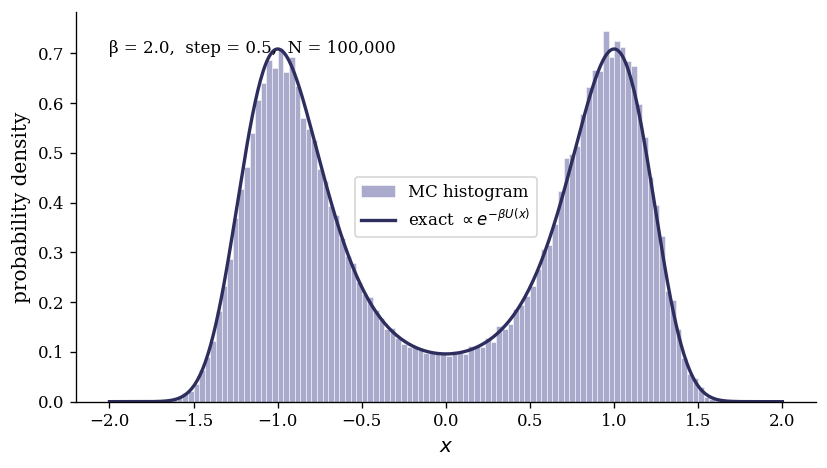

In [153]:
# Histogram vs exact Boltzmann distribution

def boltzmann(x, beta):
    """Unnormalised Boltzmann weight."""
    return np.exp(-beta * U(x))

def normalise(f, x):
    """Numerically normalise a function over x using the trapezoid rule."""
    return f / np.trapezoid(f, x)

# --- Exact distribution ---
exact   = normalise(boltzmann(x, BETA), x)

# --- Plot ---
fig, ax = plt.subplots(figsize=(7, 4))

ax.hist(traj, bins=120, range=(-2, 2), density=True, color="#aaaacc", edgecolor="white", lw=0.3, label="MC histogram")
ax.plot(x, exact, color="#2e2e5e", lw=2, label=r"exact $\propto e^{-\beta U(x)}$")

ax.set_xlabel(r"$x$")
ax.set_ylabel("probability density")
ax.text(-2, 0.7, f"β = {BETA},  step = {STEP},  N = {N_STEPS:,}")
ax.legend()
plt.tight_layout()
plt.show()

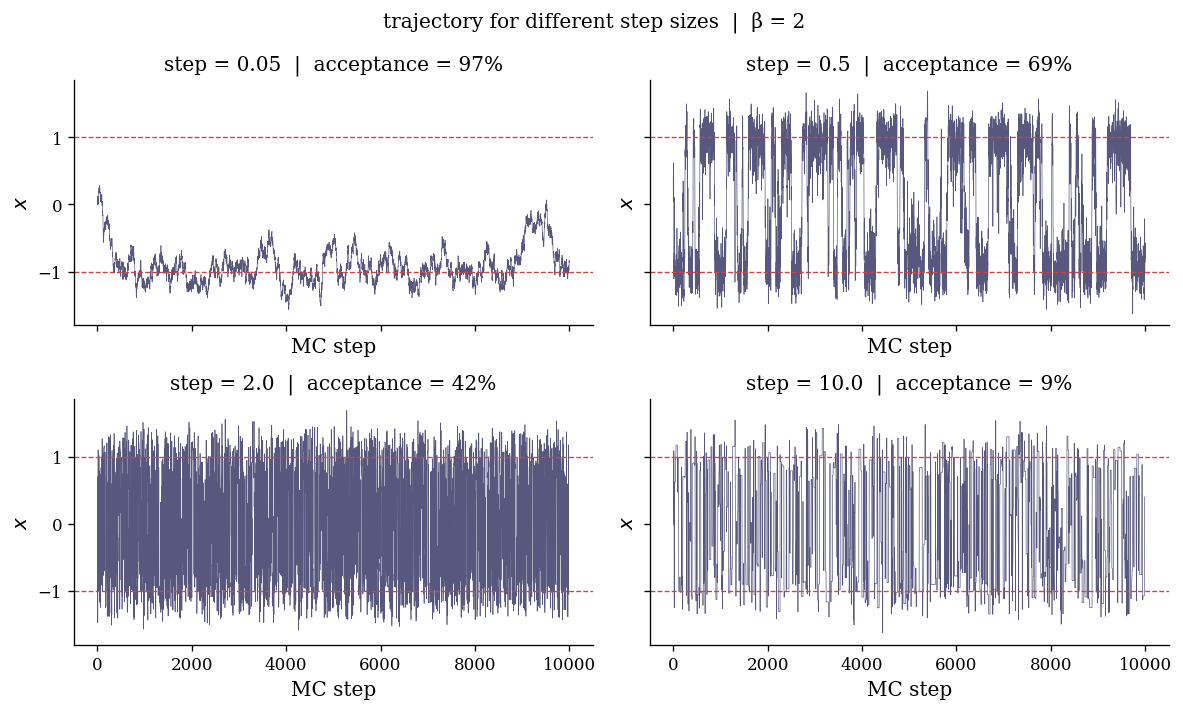

In [154]:
#  Effect of step size on acceptance rate and mixing

step_sizes = [0.05, 0.5, 2.0, 10.0]
n_steps_short = 10_000

fig, axes = plt.subplots(2, 2, figsize=(10, 6), sharex=True, sharey=True)

for ax, step in zip(axes.flat, step_sizes):
    traj_s, acc_s = run_chain(n_steps_short, x_start=0.0, beta=BETA,
                               step_size=step, rng=rng)
    ax.plot(traj_s, lw=0.4, color="#2e2e5e", alpha=0.8)
    ax.axhline( 1, color="#cc4444", lw=0.8, ls="--")
    ax.axhline(-1, color="#cc4444", lw=0.8, ls="--")
    ax.set_title(f"step = {step}  |  acceptance = {acc_s:.0%}")
    ax.set_xlabel("MC step")
    ax.set_ylabel(r"$x$")

plt.suptitle("trajectory for different step sizes  |  β = 2")
plt.tight_layout()
plt.show()

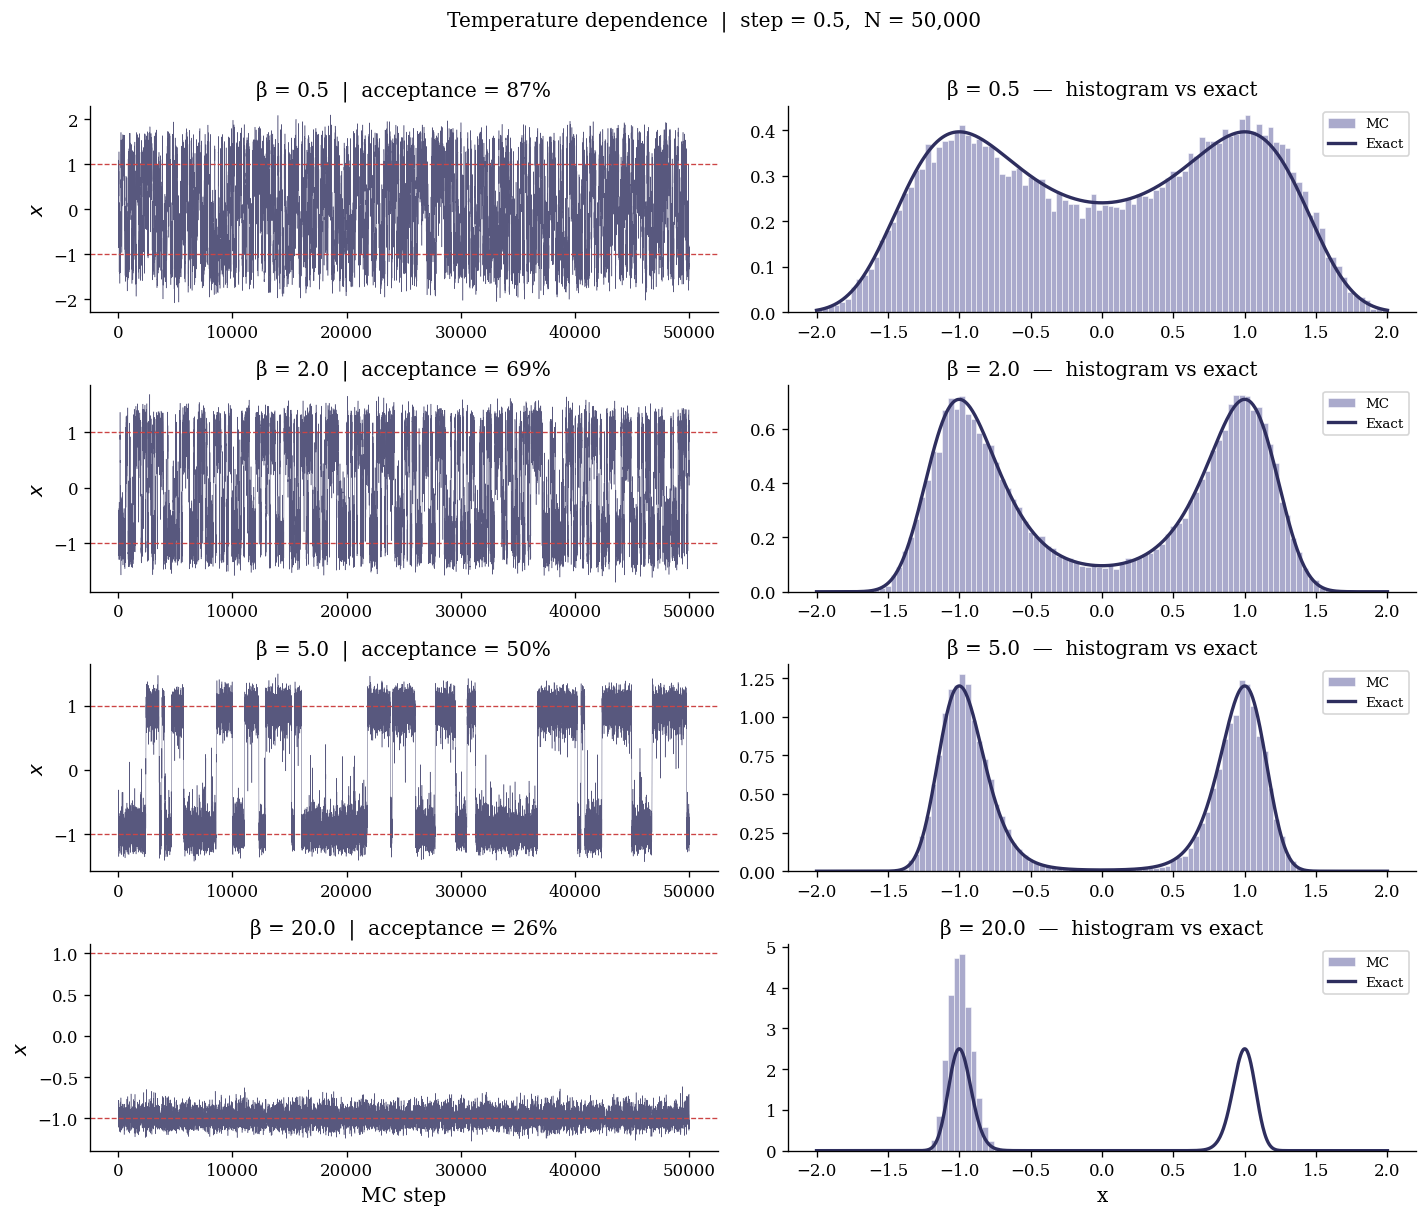

In [155]:
# Effect of temperature: ergodicity failure at low T

betas = [0.5, 2.0, 5.0, 20.0]
n_steps_temp = 50_000

fig, axes = plt.subplots(4, 2, figsize=(12, 10))

for row, beta in enumerate(betas):
    traj_t, acc_t = run_chain(n_steps_temp, x_start=-1.0, beta=beta, step_size=STEP, rng=rng)

    # --- left panel: trajectory ---
    ax_traj = axes[row, 0]
    ax_traj.plot(traj_t, lw=0.3, color="#2e2e5e", alpha=0.8)
    ax_traj.axhline( 1, color="#cc4444", lw=0.8, ls="--")
    ax_traj.axhline(-1, color="#cc4444", lw=0.8, ls="--")
    ax_traj.set_ylabel(r"$x$")
    ax_traj.set_title(f"β = {beta}  |  acceptance = {acc_t:.0%}")
    if row == 3:
        ax_traj.set_xlabel("MC step")

    # --- right panel: histogram vs exact ---
    ax_hist = axes[row, 1]
    x  = np.linspace(-2, 2, 1000)
    exact_t = boltzmann(x, beta)
    exact_t = exact_t / np.trapezoid(exact_t, x)

    ax_hist.hist(traj_t, bins=100, range=(-2, 2), density=True,
                 color="#aaaacc", edgecolor="white", lw=0.3,
                 label="MC")
    ax_hist.plot(x, exact_t, color="#2e2e5e", lw=2,
                 label="Exact")
    ax_hist.set_title(f"β = {beta}  —  histogram vs exact")
    ax_hist.legend(fontsize=8)
    if row == 3:
        ax_hist.set_xlabel("x")

plt.suptitle("Temperature dependence  |  step = 0.5,  N = 50,000", y=1.01)
plt.tight_layout()
plt.show()

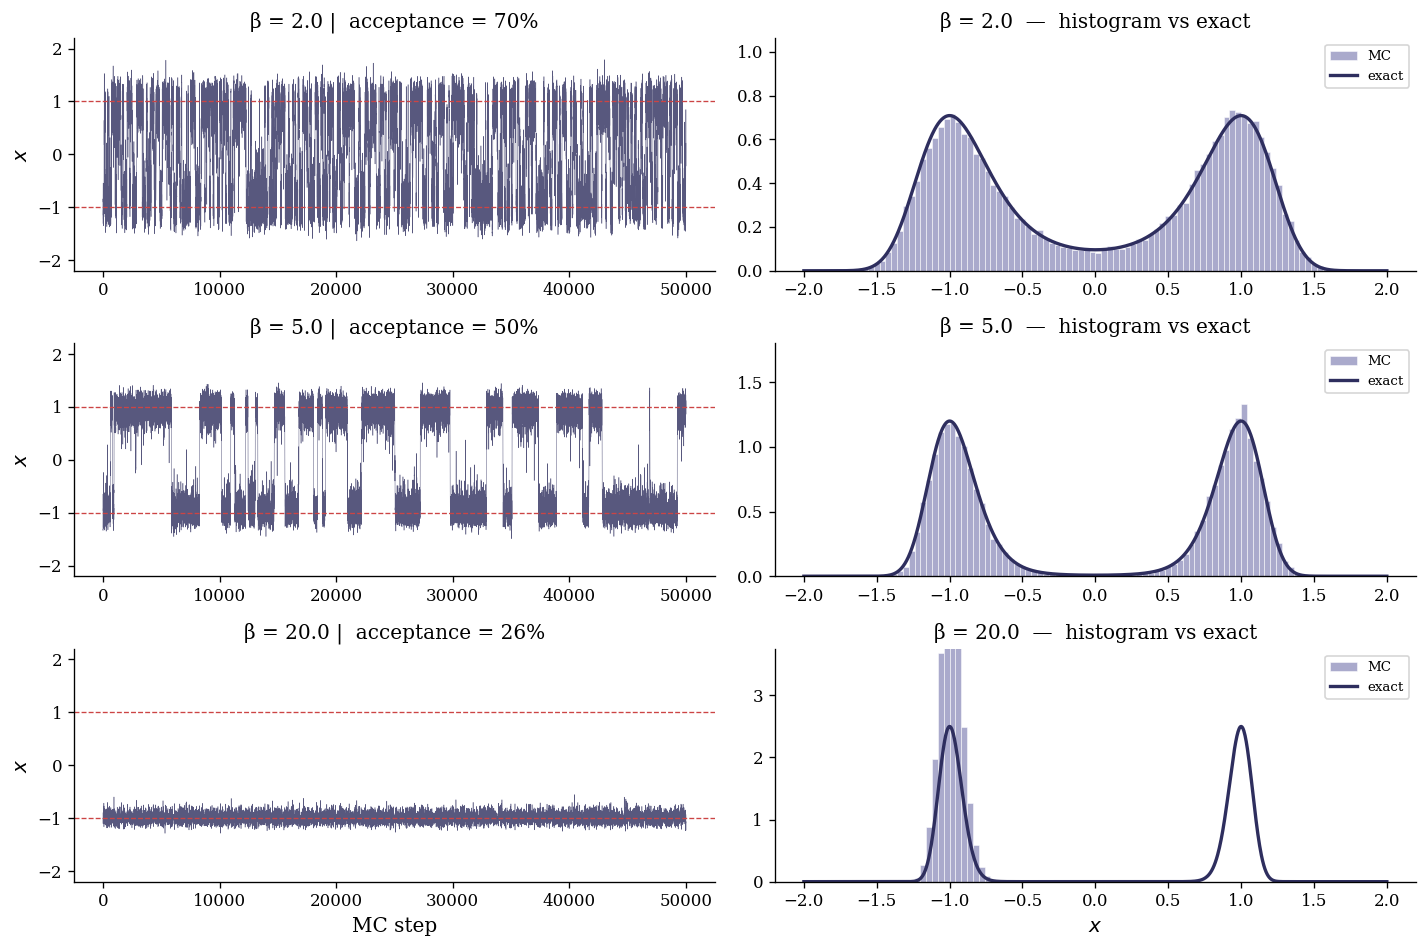

In [157]:
# Effect of temperature: ergodicity failure at low T
import time
from IPython.display import display, clear_output
betas        = [2.0, 5.0, 20.0]
n_steps_temp = 50_000
N_RUNS       = 10
for run in range(N_RUNS):

    fig, axes = plt.subplots(3, 2, figsize=(12, 8))
    for row, beta in enumerate(betas):
        traj_t, acc_t = run_chain(n_steps_temp, x_start=-1.0, beta=beta, step_size=STEP, rng=rng)

        # --- left: trajectory ---
        ax_traj = axes[row, 0]
        ax_traj.plot(traj_t, lw=0.3, color="#2e2e5e", alpha=0.8)
        ax_traj.axhline( 1, color="#cc4444", lw=0.8, ls="--")
        ax_traj.axhline(-1, color="#cc4444", lw=0.8, ls="--")
        ax_traj.set_ylabel(r"$x$")
        ax_traj.set_ylim(-2.2, 2.2)
        ax_traj.set_title(f"β = {beta} |  acceptance = {acc_t:.0%}")
        if row == 2:
            ax_traj.set_xlabel("MC step")
        # --- right: histogram vs exact ---
        ax_hist = axes[row, 1]
        x  = np.linspace(-2, 2, 1000)
        exact_t = boltzmann(x, beta)
        exact_t = exact_t / np.trapezoid(exact_t, x)
        ax_hist.hist(traj_t, bins=100, range=(-2, 2), density=True, color="#aaaacc", edgecolor="white", lw=0.3, label="MC")
        ax_hist.plot(x, exact_t, color="#2e2e5e", lw=2, label="exact")
        ax_hist.set_xlim(-2.2, 2.2)
        ax_hist.set_ylim(0, 1.5 * exact_t.max())
        ax_hist.set_title(f"β = {beta}  —  histogram vs exact")
        ax_hist.legend(fontsize=8)
        if row == 2:
            ax_hist.set_xlabel(r"$x$")
    plt.tight_layout()
    display(fig)
    clear_output(wait=True)
    plt.close(fig)
    time.sleep(0.3)